# Eigenvectors and Eigenvalues

The eigenvector of a matrix is a vector whose direction does not change when linear transformation (matrix multiplication) is performed on.

- an eigenvector only stretches or shrinks, it never rotates.
- an eigenvalue tells you by how much.

### What are Eigenvalues & Eigenvectors? 

When you multiply a matrix A by a special vector v, the result is just the same vector scaled by a number. That number is the eigenvalue λ.

Think of it this way, the matrix doesn't rotate v, it only stretches or shrinks it.

In [ ]:
A @ v = λ * v

### The Derivation (step by step)

##### Step 1: Start with the equation

In [ ]:
A @ v = λ * v

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

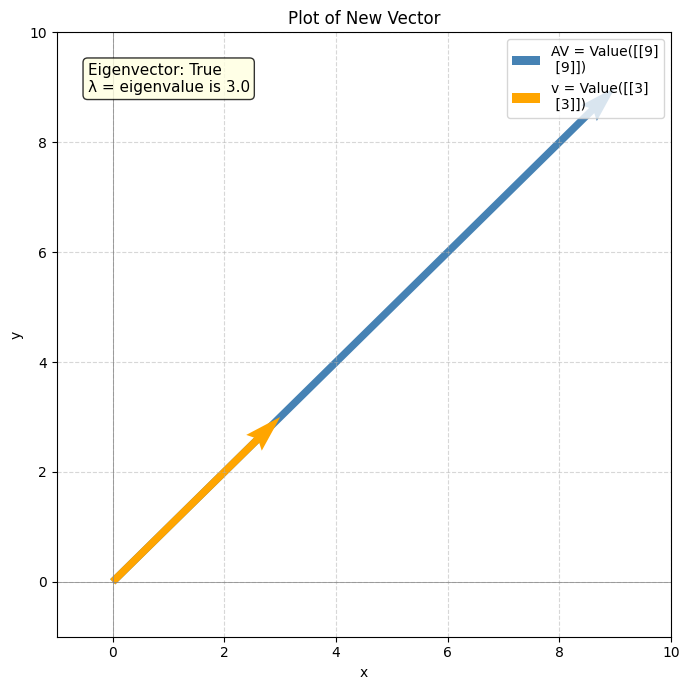

Eigenvalue λ = eigenvalue is 3.0


In [42]:
class Value:
    def __init__(self, data):
        self.data = data
    
    def __repr__(self):
        return f"Value({self.data})"
    
    def transform_vector(self, other):
        """"
            to calculate the linear transformation of
            vector = v by matrix = A
        """
        tran_vec = Value(other.data @ self.data)
        return tran_vec
    
    def is_eigenvector(self, other, tol=1e-6):
        """
            self = vector,
            other = matrix
            tol = 1e-6 -> tolerance

            To determine if vector(v) is an eigenvector of Matrix (A).

            formula:
                A @ v = λ  * v  -> all ratios (AV / v) must be equal.
                Returns (True, λ) or (False , None)

        """
        AV = self.transform_vector(other)
        nonzero = self.data != 0
        ratios = AV.data[nonzero] / self.data[nonzero]

        if np.allclose(ratios, ratios[0], atol=tol):
            eigenvalue = round(float(ratios[0]), 6)
            return True, f"eigenvalue is {eigenvalue}"
        return False, None
    
    def plot_vectors(self, other):
        """
            Plot the original vector and its transformation.
        """
        AV = self.transform_vector(other)
        is_eigenvalue, eigenvalue = self.is_eigenvector(other)

        # --- Plot ---
        origin = np.array([0,0])
        fig, ax = plt.subplots(figsize=(7, 7))

        ax.quiver(*origin, AV.data[0], AV.data[1],
                  angles='xy', scale_units='xy', scale=1,
                  color='steelblue', width=0.012, label=f'AV = {AV}')

        ax.quiver(*origin, self.data[0], self.data[1],
                  angles='xy', scale_units='xy', scale=1,
                  color='orange', width=0.012, label=f'v = {self}')
        
        
        # Annotate eigenvector result on the graph
        result_text = f'Eigenvector: {is_eigenvalue}'
        if is_eigenvalue:
            result_text += f'\nλ = {eigenvalue}'
            ax.text(0.05, 0.95, result_text,
                    transform=ax.transAxes, fontsize=11,
                    verticalalignment='top',
                    bbox=dict(boxstyle='round', 
                              facecolor='lightyellow', 
                              alpha=0.8))
            
        padding = 1
        all_vals = [self.data[0], self.data[1], AV.data[0], AV.data[1]]
        ax.set_xlim(min(0, min(all_vals)) - padding, max(all_vals) + padding)
        ax.set_ylim(min(0, min(all_vals)) - padding, max(all_vals) + padding)

        ax.axhline(0, color='gray', linewidth=0.5)
        ax.axvline(0, color='gray', linewidth=0.5)
        ax.set_xlabel('x'); ax.set_ylabel('y')
        ax.set_title('Plot of New Vector')
        ax.legend(); ax.grid(True, linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()

        # --- Print ---
        if is_eigenvalue:
            print(f'Eigenvalue λ = {eigenvalue}')

    

Av = np.array([
    [2],
    [3]
])

Bx = np.array([
    [1, 2],
    [2, 1]
])

Cv = np.array([
    [3],
    [3]
])

a = Value(Av)
b = Value(Bx)
c = Value(Cv)


# a.is_eigenvector(b)
# c.is_eigenvector(b)

# a.plot_vectors(b)

c.plot_vectors(b)
        